## Evaluation of poly(A) models

#### poly(A) tail length distributions

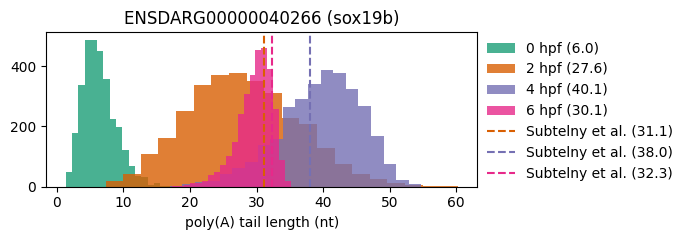

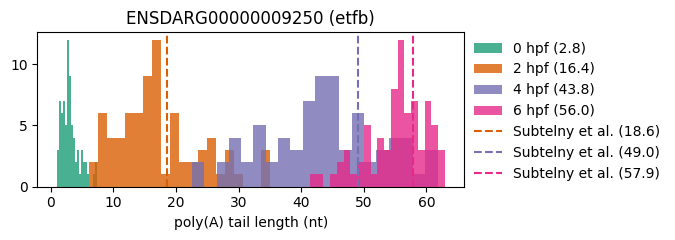

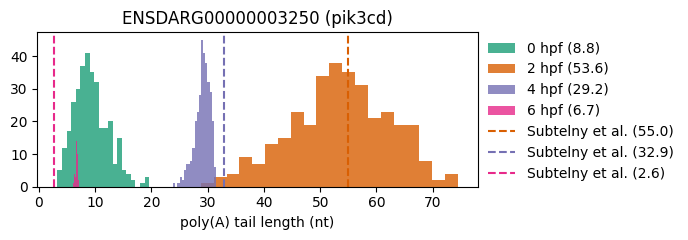

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def plot_tail_distribution2(ds, gene_id, name):
        cmap = sns.color_palette("Dark2", n_colors=5)

        tails = pd.read_csv("data/Subtelny/tail_lengths.csv")
        t2 = tails.loc[tails["GeneID"] == gene_id]["2 hpf"].item()
        t4 = tails.loc[tails["GeneID"] == gene_id]["4 hpf"].item()
        t6 = tails.loc[tails["GeneID"] == gene_id]["6 hpf"].item()
        
        P_i_0 = ds.P_true.sel(time=0)
        P_i_2 = ds.P_true.sel(time=2)
        P_i_4 = ds.P_true.sel(time=4)
        P_i_6 = ds.P_true.sel(time=6)

        fig, ax = plt.subplots(figsize=(7,2.5), )
        ax.hist(P_i_0, bins=20, color=cmap[0], alpha=0.8, label= f"0 hpf ({P_i_0.median().item():.1f})")
        ax.hist(P_i_2, bins=20, color=cmap[1], alpha=0.8, label= f"2 hpf ({P_i_2.median().item():.1f})")
        ax.hist(P_i_4, bins=20, color=cmap[2], alpha=0.8, label= f"4 hpf ({P_i_4.median().item():.1f})")
        ax.hist(P_i_6, bins=20, color=cmap[3], alpha=0.8, label= f"6 hpf ({P_i_6.median().item():.1f})")

        ax.axvline(x=t2, color=cmap[1], ls="--", label=f"Subtelny et al. ({t2})")
        ax.axvline(x=t4, color=cmap[2], ls="--", label=f"Subtelny et al. ({t4})")
        ax.axvline(x=t6, color=cmap[3], ls="--", label=f"Subtelny et al. ({t6})")
        ax.legend(frameon=False, loc=(1.01, 0.0))
        ax.set(title=f"{gene_id} ({name})", xlabel="poly(A) tail length (nt)")

        plt.tight_layout()
        plt.savefig(f"figures/ib_model/{gene_id}_polyA_tail_distribution_ib2.png")
        plt.show()
        #plt.close()
d = pd.read_csv("data/inc_winata_genes.csv")
genes = ["ENSDARG00000040266", "ENSDARG00000009250",  "ENSDARG00000003250" ]

for gene_id in genes:
        name = d.loc[d["GeneID"] == gene_id, "GeneName"].item()
        ds = xr.load_dataset(f"results/{gene_id}_ib_model_fit.nc")
        plot_tail_distribution2(ds, gene_id, name)

In [2]:
pd.read_csv("data/Subtelny/tail_lengths.csv")

,GeneID,TranscriptID,GeneName,2 hpf,4 hpf,6 hpf
0,ENSDARG00000038876,ENSDART00000134975,zgc:101569,26.1,47.1,37.7
1,ENSDARG00000040266,ENSDART00000058910,sox19b,31.1,38.0,32.3
2,ENSDARG00000062272,ENSDART00000089834,afg3l2,20.0,30.9,30.5
3,ENSDARG00000019791,ENSDART00000013409,prmt3,19.2,58.2,28.4
4,ENSDARG00000062187,ENSDART00000089622,kif14,42.7,37.4,72.7
...,...,...,...,...,...,...
139,ENSDARG00000070604,ENSDART00000103857,zgc:162509,33.5,36.2,13.8
140,ENSDARG00000010169,ENSDART00000011143,myd88,29.0,31.2,67.7
141,ENSDARG00000009266,ENSDART00000048507,uevld,29.7,25.8,41.2
142,ENSDARG00000101542,ENSDART00000146311,si:dkeyp-53d3.5,20.1,41.5,59.7


In [23]:
d

<xarray.Dataset> Size: 61MB
Dimensions:          (time: 50, ensembl_gene_id: 36570, source: 4)
Coordinates:
  * time             (time) float64 400B 0.0 0.75 0.875 ... 96.0 103.2 120.0
  * ensembl_gene_id  (ensembl_gene_id) <U18 3MB 'ENSDARG00000000001' ... 'ENS...
  * source           (source) <U12 192B 'BK' 'JN' 'Pauli et al.' 'White et al.'
Data variables:
    y                (time, ensembl_gene_id, source) float64 59MB nan ... 0.0

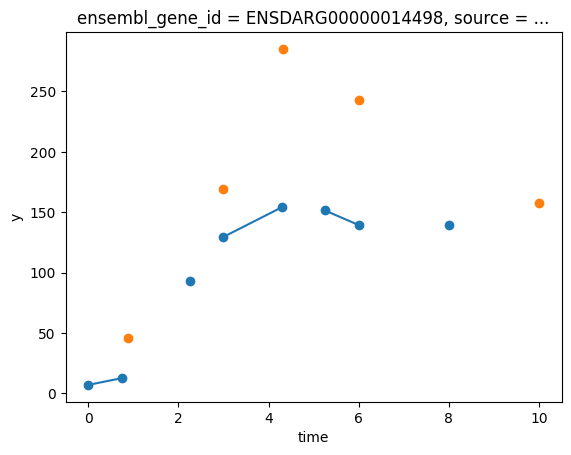

In [25]:
d = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean_wSource.nc").sel(time=slice(0,10))
d1 = d.sel(ensembl_gene_id = "ENSDARG00000014498")

d1.y.sel(source="White et al.").plot.line("o-")
d1.y.sel(source='Pauli et al.').plot.line("o-")

In [ ]:
gene_id = "ENSDARG00000040266"
ds = xr.load_dataset(f"results/{gene_id}_ib_model_fit.nc")
P_i_0 = ds.P_true.sel(time=0)
P_i_2 = ds.P_true.sel(time=2)
P_i_4 = ds.P_true.sel(time=4)
P_i_6 = ds.P_true.sel(time=6)

#### Average tail lengths

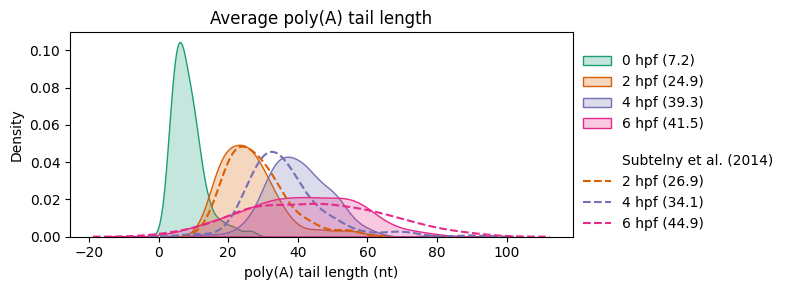

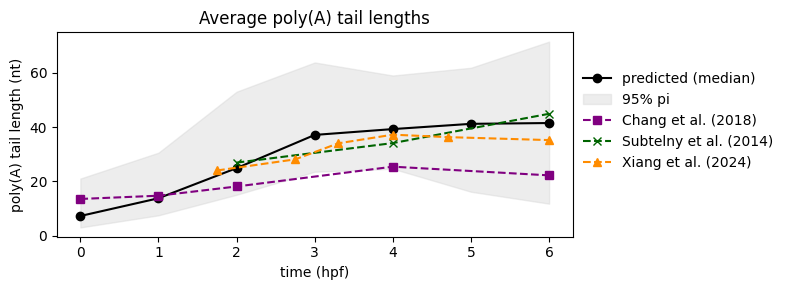

C:\Users\mgrho\AppData\Local\Temp\ipykernel_15448\1888956520.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


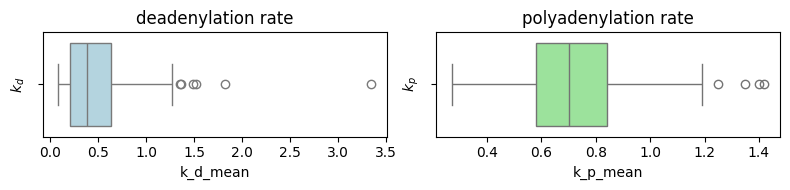

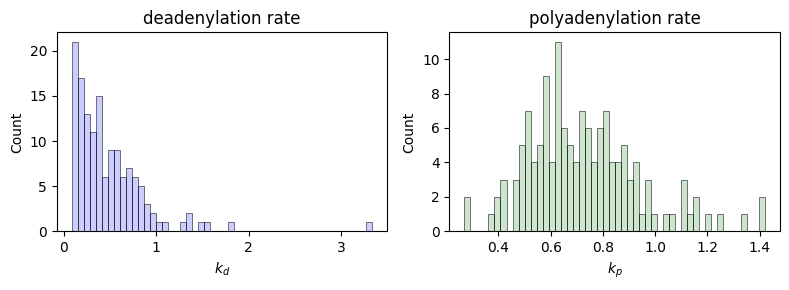

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = "PolyAModel_mean_approx_White_tails"
na_genes = ["ENSDARG00000070801", "ENSDARG00000100072", "ENSDARG00000053138", "ENSDARG00000038835", "ENSDARG00000071562"]
genes = pd.read_csv("data/inc_winata_genes.csv")
genes = genes[~genes["GeneID"].isin(na_genes)]

P_dist = pd.read_csv(f"{path}/P_values_by_gene.csv")
P_dist = P_dist[P_dist["gene_id"].isin(genes.GeneID)]
P_dist = P_dist[~P_dist["gene_id"].isin(na_genes)]

tails = pd.read_csv("data/Subtelny/tail_lengths.csv")
tails = tails[~tails["GeneID"].isin(na_genes)]

params = pd.read_csv(f"{path}/parameter_fit_summary.csv")
params = params[~params["GeneID"].isin(na_genes)]

t0 = P_dist["P_time0"]
t1 = P_dist["P_time1"]
t2 = P_dist["P_time2"]
t3 = P_dist["P_time3"]
t4= P_dist["P_time4"]
t5 = P_dist["P_time5"]
t6 = P_dist["P_time6"]

times = [t0, t2, t4, t6]
labels = ["0", "2", "4", "6"]
cmap = sns.color_palette("Dark2", n_colors=5)

st2 = tails["2 hpf"].median()
st4 = tails["4 hpf"].median()
st6 = tails["6 hpf"].median()

## -------- Histplot -----------------
plt.figure(figsize=(8,3))
sns.kdeplot(tails["2 hpf"], cumulative=False, label=f"2 hpf ({st2:.1f})", color=cmap[1], fill=True)
sns.kdeplot(tails["4 hpf"], cumulative=False, label=f"4 hpf ({st4:.1f})", color=cmap[2], fill=True)
sns.kdeplot(tails["6 hpf"], cumulative=False, label=f"6 hpf ({st6:.1f})", color=cmap[3], fill=True)
#plt.xlim(0, 150)
plt.axvline(tails["2 hpf"].median(), color=cmap[1], ls="--", label="2 hpf (Subtelny)")
plt.axvline(tails["4 hpf"].median(), color=cmap[2], ls="--",  label="4 hpf (Subtelny)")
plt.axvline(tails["6 hpf"].median(), color=cmap[3], ls="--",  label="6 hpf (Subtelny)")

plt.legend(frameon=False, loc=(1.01, 0.0))
plt.title("mean poly(A) tail length (Subtelny et al., 2014)")
plt.xlabel("poly(A) tail length (nt)")
plt.tight_layout()
#plt.savefig("figures/kde_mean_polyA_tail_length_subtelny.png")
plt.close()


## -------- Histplot -----------------
plt.figure(figsize=(8,3))
for i, t in enumerate(times):
    #sns.histplot(t, kde=True, cumulative=False,  element="step", stat="density", 
    #             label=f"{labels[i]} hpf ({t.median():.1f})", color=cmap[i], alpha=0.2, edgecolor=None)
    sns.kdeplot(t, cumulative=False, label=f"{labels[i]} hpf ({t.median():.1f})", color=cmap[i], fill=True)
#plt.xlim(0, 150)
#plt.axvline(13.5, color=cmap[0], ls="--", label="0 hpf (Chang)")
#plt.axvline(tails["2 hpf"].median(), color=cmap[1], ls="--", label="2 hpf (Subtelny)")
#plt.axvline(tails["4 hpf"].median(), color=cmap[2], ls="--",  label="4 hpf (Subtelny)")
#plt.axvline(tails["6 hpf"].median(), color=cmap[3], ls="--",  label="6 hpf (Subtelny)")
plt.scatter(x=0, y=0, c="white", s=1, label="\nSubtelny et al. (2014)")
sns.kdeplot(tails["2 hpf"], cumulative=False, label=f"2 hpf ({st2:.1f})", color=cmap[1], fill=False, ls="--")
sns.kdeplot(tails["4 hpf"], cumulative=False, label=f"4 hpf ({st4:.1f})", color=cmap[2], fill=False, ls="--")
sns.kdeplot(tails["6 hpf"], cumulative=False, label=f"6 hpf ({st6:.1f})", color=cmap[3], fill=False, ls="--")

plt.legend(frameon=False, loc=(1.01, 0.0))
plt.title("Average poly(A) tail length")
plt.xlabel("poly(A) tail length (nt)")
plt.tight_layout()
plt.savefig("figures/kde_mean_polyA_tail_length_white.png")
plt.show()


## -------- Trajectories -----------------
plt.figure(figsize=(8,3))
t = [0, 1, 2, 3, 4 ,5, 6]
means = np.array([t0.median(), t1.median(), t2.median(), t3.median(), t4.median(), t5.median(), t6.median(),])
q025 = np.array([t0.quantile(0.025), t1.quantile(0.025), t2.quantile(0.025), t3.quantile(0.025), t4.quantile(0.025), t5.quantile(0.025), t6.quantile(0.025),])
q975 = np.array([t0.quantile(0.975), t1.quantile(0.975), t2.quantile(0.975), t3.quantile(0.975), t4.quantile(0.975), t5.quantile(0.975), t6.quantile(0.975),])
plt.plot(t, means, "ko-", label="predicted (median)")
plt.fill_between(t, q025,q975, alpha=0.4, color="lightgrey", label="95% pi")
plt.plot([0, 1, 2, 4, 6], [13.5, 14.7, 18.1, 25.4, 22.2], "s--", c="purple", label="Chang et al. (2018)")
#plt.plot([2, 4, 6], [29.4, 44.0, 58.9], "x--", c="darkgreen", label="Subtelny et al. (2014)")
plt.plot([2, 4, 6], [tails["2 hpf"].median(), tails["4 hpf"].median(), tails["6 hpf"].median()], "x--", c="darkgreen", label="Subtelny et al. (2014)")
plt.plot([1.75, 2.75, 3.3, 4, 4.7, 6], [24, 28.1, 34, 37.2, 36.3, 35.2], "^--", c="darkorange", label="Xiang et al. (2024)")
plt.xlabel("time (hpf)")
plt.title("Average poly(A) tail lengths")
plt.ylabel("poly(A) tail length (nt)")
plt.legend(frameon=False, loc=(1.01, 0.3))
plt.tight_layout()
plt.savefig("figures/mean_polyA_tail_length_white.png")
plt.show()

# NRMSE -> P based
gof1 = pd.read_csv(f"{path}/goodness_of_fit_summary.csv")
gof1 = gof1[gof1["GeneID"].isin(genes.GeneID)]

plt.figure(figsize=(6,4))
sns.histplot(gof1["NRMSE"], bins=30, kde=True, color="blue", alpha=0.2, edgecolor=None)
#sns.histplot(gof["NRMSE"], bins=30, kde=True, color="orange", alpha=0.2, edgecolor=None, label="Winata")
plt.legend()
plt.title("NRMSE")
plt.xlabel("NRMSE")
plt.close()

data = gof1[["GeneID","NRMSE"]]
ds = P_dist[["gene_id", "P_time0", "P_time3", "y0", "True_diff_t6"]]
data1 = ds.merge(data, left_on="gene_id", right_on="GeneID")
data1

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,2))
sns.boxplot(params, x="k_d_mean", color="lightblue",ax=ax1)
sns.boxplot(params, x="k_p_mean", color="lightgreen", ax=ax2)
ax1.set(title="deadenylation rate", ylabel="$k_d$")
ax2.set(title="polyadenylation rate", ylabel="$k_p$")
plt.tight_layout()
plt.savefig("figures/rates_kd_kp_box.png")
plt.show()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,3))
sns.histplot(params.k_d_mean, bins=50, kde=False, color="blue", alpha=0.2, ax=ax1 )
ax1.set(title="deadenylation rate", xlabel="$k_d$")
#plt.figure(figsize=(5,4))
sns.histplot(params.k_p_mean, bins=50, kde=False, color="green", alpha=0.2, ax= ax2)
ax2.set(title="polyadenylation rate", xlabel="$k_p$")
plt.tight_layout()
plt.savefig("figures/rates_kd_kp_hist.png")
plt.show()

In [81]:
params[["k_d_mean", "k_p_mean"]].quantile([0.5, 0.025, 0.975])
params[["k_d_mean", "k_p_mean"]].max()
params[["k_d_mean", "k_p_mean"]].min()

k_d_mean    0.0878
k_p_mean    0.2700
dtype: float64

#### GOF

Text(0.5, 1.0, 'TPM biased')

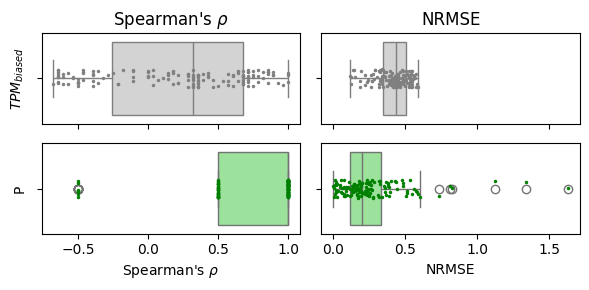

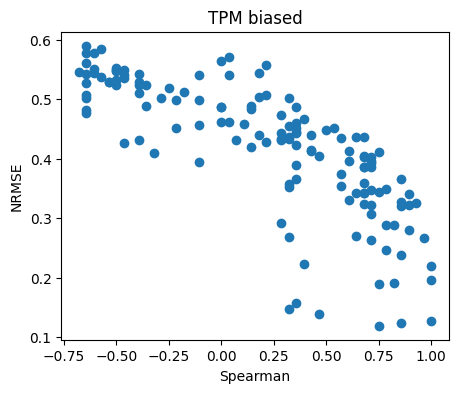

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#path = "White_tails"

metrics = pd.read_csv(f"{path}/metrics.csv")
metricsP = pd.read_csv(f"{path}/metricsP.csv")
metricsP = metricsP.loc[~metricsP["Spearman"].isna()]
#metricsP = metricsP.loc[metricsP["NRMSE_range"] <2]

fig, ax = plt.subplots(2,2, figsize=(6,3), sharex="col")
ax = ax.flatten()
sns.boxplot(metrics, x="Spearman",  ax=ax[0], color="lightgray")
sns.stripplot(metrics, x="Spearman",  ax=ax[0], color="grey", marker=".")
sns.boxplot(metrics, x="NRMSE_range", ax=ax[1], color="lightgray")
sns.stripplot(metrics, x="NRMSE_range",  ax=ax[1], color="grey", marker=".")

sns.boxplot(metricsP, x="Spearman", ax=ax[2], color="lightgreen")
sns.stripplot(metricsP, x="Spearman",  ax=ax[2], color="green", marker=".")
sns.boxplot(metricsP, x="NRMSE_range", ax=ax[3], color="lightgreen")
sns.stripplot(metricsP, x="NRMSE_range",  ax=ax[3], color="green", marker=".")
ax[0].set(xlabel="Spearman's $\\rho$", ylabel="$TPM_{biased}$", title="Spearman's $\\rho$")
ax[1].set(xlabel="NRMSE", title="NRMSE")
ax[2].set(xlabel="Spearman's $\\rho$", ylabel="P")
ax[3].set(xlabel="NRMSE", )
plt.tight_layout()
plt.savefig("figures/gof_box.png")


plt.figure(figsize=(5, 4))
plt.scatter(metrics["Spearman"], metrics["NRMSE_range"],)
plt.xlabel("Spearman")
plt.ylabel("NRMSE")
plt.title("TPM biased")

In [90]:
metrics[["Spearman", "NRMSE_range"]].quantile([0.5, 0.025, 0.975])
metricsP[["Spearman", "NRMSE_range"]].quantile([0.5, 0.025, 0.975])

len(metrics[metrics["Spearman"] > 0.5]) / len(metrics)
len(metrics[metrics["NRMSE_range"] < 0.2]) / len(metrics)

0.06428571428571428

In [92]:
genes = ["ENSDARG00000040266", "ENSDARG00000009250",  "ENSDARG00000003250" ]
metricsP.loc[metricsP["GeneID"].isin(genes)]
metrics.loc[metrics["GeneID"].isin(genes)]
#params.loc[params["GeneID"].isin(genes)]

,GeneID,Spearman,NRMSE_range
50,ENSDARG00000003250,0.785714,0.246194
53,ENSDARG00000040266,0.321429,0.501902
58,ENSDARG00000009250,0.857143,0.123895


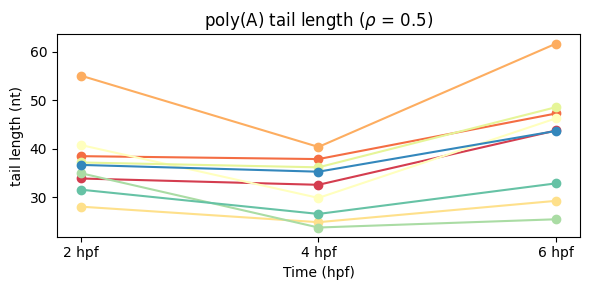

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tails = pd.read_csv("data/Subtelny/tail_lengths.csv")
a = tails.loc[tails["GeneID"].isin(metricsP.loc[metricsP["Spearman"] < 0.5].GeneID.values)]
df_plot = a.set_index("GeneName")[["2 hpf", "4 hpf", "6 hpf"]]
cmap = sns.color_palette("Spectral", n_colors=len(a))

plt.figure(figsize=(6, 3))

for i, gene in enumerate(df_plot.index):
    plt.plot(
        df_plot.columns,
        df_plot.loc[gene],
        marker="o",
        color=cmap[i],
        label=gene
    )

plt.xlabel("Time (hpf)")
plt.ylabel("tail length (nt)")
plt.title("poly(A) tail length ($\\rho$ = 0.5)")
#plt.legend(bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
#plt.savefig("figures/moderate_rho_P.png")
plt.show()

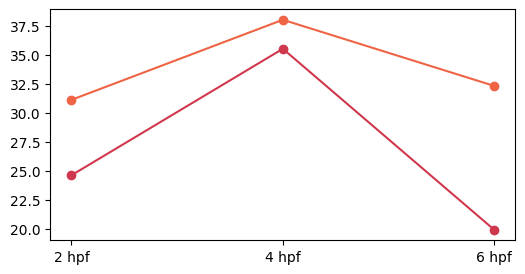

In [ ]:
# compare median & mean tail lengths
tails = pd.read_csv("data/Subtelny/tail_lengths_median.csv")
genes = ["ENSDARG00000040266", "ENSDARG00000009250",  "ENSDARG00000003250" ]
gene = genes[0]
df_plot = tails.set_index("GeneID")[["2 hpf", "4 hpf", "6 hpf"]]
plt.figure(figsize=(6, 3))
plt.plot(    df_plot.columns,    df_plot.loc[gene],    marker="o",    color=cmap[0],    label=gene)
tails = pd.read_csv("data/Subtelny/tail_lengths.csv")
df_plot = tails.set_index("GeneID")[["2 hpf", "4 hpf", "6 hpf"]]
plt.plot(    df_plot.columns,    df_plot.loc[gene],    marker="o",    color=cmap[1],    label=gene)

### Prepare tail length data

In [11]:
import pandas as pd
genes = pd.read_csv("data/inc_winata_genes.csv")
ds = pd.DataFrame(columns=["GeneID", "TranscriptID","GeneName", "2 hpf", "4 hpf","6 hpf",])

# read tab-separated file
tail2 = pd.read_csv("data/Subtelny/GSE52809_Dre_mock_2hpf.txt", sep="\t")
tail4 = pd.read_csv("data/Subtelny/GSE52809_Dre_mock_4hpf.txt", sep="\t", skiprows=2)
tail6 = pd.read_csv("data/Subtelny/GSE52809_Dre_mock_6hpf.txt", sep="\t", skiprows=2)

tail2 = tail2[tail2["Gene name"].isin(genes.GeneName)]
tail4 = tail4[tail4["Gene name"].isin(genes.GeneName)]
tail6 = tail6[tail6["Gene name"].isin(genes.GeneName)]

ds["TranscriptID"] = tail2["Transcript ID"]
gmap = dict(zip(tail2["Transcript ID"].values,tail2["Gene name"].values,))
namemap = dict(zip(genes["GeneName"].values,genes["GeneID"].values,))
tmap2 = dict(zip(tail2["Transcript ID"].values, tail2["Mean TL"].values,))
tmap4 = dict(zip(tail4["Transcript ID"].values, tail4["Mean TL"].values,))
tmap6 = dict(zip(tail6["Transcript ID"].values, tail6["Mean TL"].values,))

#tmap2 = dict(zip(tail2["Transcript ID"].values, tail2["Median TL"].values,))
#tmap4 = dict(zip(tail4["Transcript ID"].values, tail4["Median TL"].values,))
#tmap6 = dict(zip(tail6["Transcript ID"].values, tail6["Median TL"].values,))

ds["GeneName"] = ds["TranscriptID"].map(gmap)
ds["GeneID"] = ds["GeneName"].map(namemap)
ds["2 hpf"] = ds["TranscriptID"].map(tmap2)
ds["4 hpf"] = ds["TranscriptID"].map(tmap4)
ds["6 hpf"] = ds["TranscriptID"].map(tmap6)
#ds.to_csv("data/Subtelny/tail_lengths.csv", index=False)
ds.sort_values("GeneName")

,GeneID,TranscriptID,GeneName,2 hpf,4 hpf,6 hpf
4311,ENSDARG00000034883,ENSDART00000135124,acbd5a,55.1,40.4,61.7
1529,ENSDARG00000043213,ENSDART00000063437,adam17a,51.5,70.1,39.0
6913,ENSDARG00000002912,ENSDART00000026258,adipor1a,24.7,28.0,53.2
4044,ENSDARG00000039429,ENSDART00000057605,adka,45.6,89.4,74.9
331,ENSDARG00000062272,ENSDART00000089834,afg3l2,20.0,30.9,30.5
...,...,...,...,...,...,...
12918,ENSDARG00000003017,ENSDART00000008490,zgc:55512,36.7,35.3,43.7
12466,ENSDARG00000055162,ENSDART00000077484,zhx2,36.4,41.6,65.2
5502,ENSDARG00000020494,ENSDART00000014232,znf330,23.4,38.8,55.7
1404,ENSDARG00000071868,ENSDART00000106654,znf711,26.2,27.9,56.3


### Scaling factor

In [32]:
import pandas as pd
tpm = pd.read_csv("data/tpms_white_pauli_JN_BK.csv")
mean_L = tpm.transcript_length.mean() / 1000
tpm = tpm[tpm["transcript_is_canonical"] == 1.0]
tpm.sort_values("ensembl_gene_id")
print(mean_L)
print(1e6/(3.8e6/mean_L)) # scaling factor

1.9421834910377722
0.5111009186941505


### Pretty plots - functions

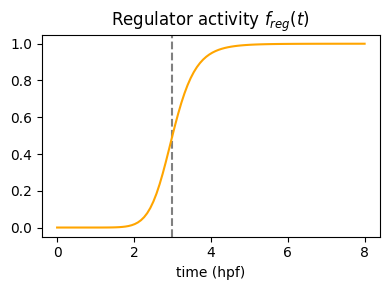

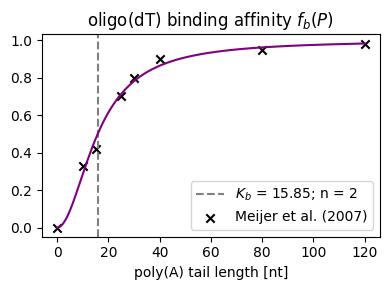

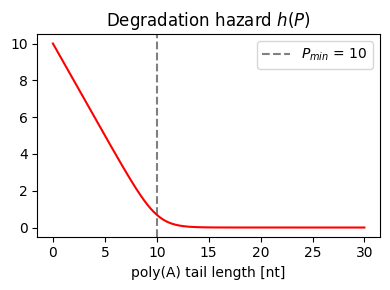

In [9]:
import numpy as np
import matplotlib.pyplot as plt


""" Regulator Activity """

def reg2(t, t_on=3, s=10):
    return t**s / ( t**s + (t_on)**s)

t = np.linspace(0, 8, 100)
fig, ax = plt.subplots(figsize=(4,3))
ax.axvline(x=3, ls="--", c="grey",)
ax.plot(t, reg2(t), c="orange")

ax.set(xlabel="time (hpf)", title= "Regulator activity $f_{reg}(t)$")
plt.tight_layout()
plt.savefig("figures/reg_activity.png")

""" Binding Affinity """

P_cap = 15.85
n_cap = 2
P = np.linspace(0, 120, 1001)
nt = np.array([0, 10, 15, 25, 30, 40, 80, 120])
frac = np.array([1, 0.67, 0.58, 0.3, 0.2, 0.1, 0.05, 0.02])
eff = 1 - frac 

'''Meijer: capture efficiency
 ~ 70 % at 25 nt
 ~ 80 % at 30 nt .. '''

def polyA_enrichment_step(P, K_b, n):
       '''
       sequencing capture bias:
       long polyA -> more oligo(dT) captures
       '''
       f_binding = P**n / (K_b**n + P**n)
       return f_binding

fig, ax = plt.subplots(figsize=(4,3))

ax.axvline(x=P_cap, ls="--", c="grey", label="$K_b$"+f" = {P_cap}; n = {n_cap}")
ax.scatter(nt, eff, marker="x", c="k", label="Meijer et al. (2007)") 
ax.plot(P, polyA_enrichment_step(P, P_cap, n_cap), c="purple")
ax.set(xlabel="poly(A) tail length [nt]", title=f"oligo(dT) binding affinity $f_b(P)$")
ax.legend()
plt.tight_layout()
plt.savefig("figures/binding_affinity.png")


""" degradation probability """

P = np.linspace(0, 30, 1001)
P_min = 10

from scipy import special
h = special.softplus(P_min - P)  # = np.log(1 + np.exp((P_min - P)))

fig, ax = plt.subplots(figsize=(4,3))
ax.axvline(x=P_min, ls="--", c="grey", label="$P_{min}$"+f" = {P_min}")
ax.plot(P,  h, c="red")
ax.set(xlabel="poly(A) tail length [nt]", title="Degradation hazard $h(P)$")
ax.legend()
plt.tight_layout()
plt.savefig("figures/Degradation_hazard.png")

In [6]:
## fitting binding affinity

## fitting of Hill curve

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def hill_function(nt, K, n):
    return (nt**n) / (K**n + nt**n)

nt = np.array([0, 10, 15, 25, 30, 40, 80, 120])
frac = np.array([1, 0.67, 0.58, 0.3, 0.2, 0.1, 0.05, 0.02])
eff = 1 - frac 

# Initial guesses for K and n
initial_guess = [15, 2] 

popt, pcov = curve_fit(hill_function, nt, eff, p0=initial_guess)
K_fit, n_fit = popt

print(f"Fitted K = {K_fit:.2f}, n = {n_fit:.2f}")


Fitted K = 15.85, n = 2.01
